In [1]:
from __future__ import print_function
import argparse, random, pickle
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision import transforms as T
from torch.optim.lr_scheduler import StepLR

import matplotlib.pyplot as plt
from PIL import Image


In [ ]:
resnet = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights)
resnet = torch.nn.Sequential(*(list(resnet.children())[:-1]))
resnet.eval()

im = Image.open("../../data/halves/t1/similar_0_1.png")
im = im.convert('RGB')
imnp = np.array(im)


output = resnet(torchvision.transforms.functional.to_tensor(im).unsqueeze(0))
print(output.shape)
print(output.view(output.size()[0], -1).shape)
print(output.squeeze().shape)
print(torch.cat((output, output), 1).shape)
print(torch.cat((output.view(output.size()[0], -1), output.view(output.size()[0], -1)), 1).shape)
print(torch.cat((output.squeeze(), output.squeeze())).shape)
resnet
output.view(output.size()[0], -1)

In [2]:
class ImagePairDataset(torch.utils.data.Dataset):
    def __init__(self, arrays, labels, vit = False):
        if vit:
            self.transform = T.Compose([T.ToPILImage(), T.Resize((224,224)), T.ToTensor()])
        else:
            self.transform = T.Compose([T.ToPILImage(), T.Resize((256,256)), T.ToTensor()])
        self.arrays = arrays
        self.labels = labels
        self.image_pairs = self.load_image_pairs()

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):
        # image1, image2 = torch.from_numpy(self.arrays[idx][0]), torch.from_numpy(self.arrays[idx][1])
        image1 = self.transform(self.arrays[idx][0])
        image2 = self.transform(self.arrays[idx][1])
        label = torch.as_tensor(self.labels[idx])

        return image1, image2, label

    def load_image_pairs(self):
        image_pairs = [torch.from_numpy(i) for i in self.arrays]
        # image_labels = [i for i in self.labels]
        return image_pairs

In [3]:
# MRI DATA
# with open('../siamese/data/pairs_Gray_90_randshape.pkl', 'rb') as f:
with open('../siamese/data/pairs_normal_RGB_902.pkl', 'rb') as f:
    data = pickle.load(f)
pairs_train_mri_noise= data['pairs_train_mri']
labels_train_mri_noise = data['labels_train_mri']
pairs_test_mri_noise = data['pairs_test_mri']
labels_test_mri_noise = data['labels_test_mri']

train_dataset = ImagePairDataset(pairs_train_mri_noise, labels_train_mri_noise, vit=True)
test_dataset = ImagePairDataset(pairs_test_mri_noise, labels_test_mri_noise, vit=True)

In [6]:
train_dataset[0][0].shape

torch.Size([3, 224, 224])

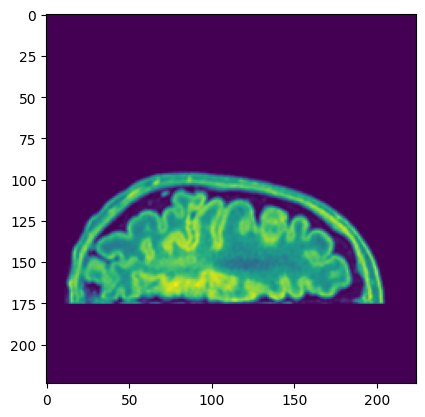

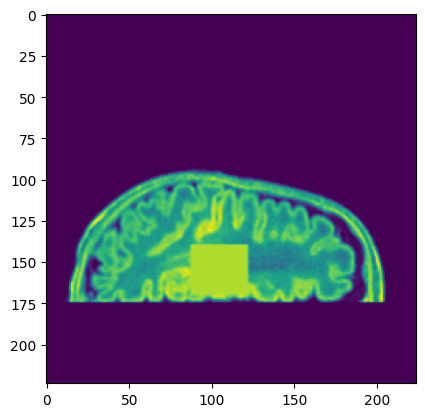

In [17]:
plt.imshow(train_dataset[3][0][0].numpy().squeeze())
plt.show()
plt.imshow(train_dataset[3][1][0].numpy().squeeze())
plt.show()

In [7]:
resnet = torchvision.models.resnet18(weights=None)
weights = torchvision.models.ResNet18_Weights.DEFAULT
preprocess = weights.transforms()
preprocess

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [8]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
weights.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [9]:
weights = torchvision.models.ViT_L_32_Weights.DEFAULT
weights.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [2]:
class SiameseNetwork(nn.Module):
    """
    """
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        # get resnet model
        self.resnet = torchvision.models.resnet18(weights=None)

        # over-write the first conv layer to be able to read MNIST images
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.fc_in_features = self.resnet.fc.in_features

        # remove the last layer of resnet18 (linear layer which is before avgpool layer)
        self.resnet = torch.nn.Sequential(*(list(self.resnet.children())[:-1]))

        # add linear layers to compare between the features of the two images
        self.fc = nn.Sequential(
            nn.Linear(self.fc_in_features * 2, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 1),
        )

        self.sigmoid = nn.Sigmoid()

        self.resnet.apply(self.init_weights)
        self.fc.apply(self.init_weights)

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            m.bias.data.fill_(0.01)

    def forward_once(self, x):
        output = self.resnet(x)
        output = output.view(output.size()[0], -1)
        return output

    def forward(self, input1, input2):
        # get two images' features
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)

        # concatenate both images' features
        output = torch.cat((output1, output2), 1)

        # pass the concatenation to the linear layers
        output = self.fc(output)

        # pass the out of the linear layers to sigmoid layer
        output = self.sigmoid(output)

        return output

In [3]:
effnet = torchvision.models.efficientnet_b0(weights=None)
next(effnet.features.children())
effnet.features[0][0] = nn.Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
effnet.classifier[1].in_features

# torch.nn.Sequential(*(list(effnet.children())[:-1]))

1280

In [4]:
resnet = torchvision.models.resnet18(weights=None)
list(resnet.children())[-1]


Linear(in_features=512, out_features=1000, bias=True)

In [3]:
vggnet = torchvision.models.vgg19(weights=torchvision.models.VGG19_Weights.DEFAULT)
list(vggnet.children())[-1]

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [6]:
vggnet

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [11]:
vggnet.classifier[0]

Linear(in_features=25088, out_features=4096, bias=True)

In [5]:
class SiameseNetwork2(nn.Module):
    """
    """
    def __init__(self):
        super(SiameseNetwork2, self).__init__()
        # get resnet model
        self.effnet = torchvision.models.efficientnet_v2_l(weights=None)

        # over-write the first conv layer to be able to read MNIST images
        self.effnet.features[0][0] = nn.Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        self.fc_in_features = self.effnet.classifier[1].in_features

        # remove the last layer of resnet18 (linear layer which is before avgpool layer)
        self.effnet = torch.nn.Sequential(*(list(self.effnet.children())[:-1]))

        # add linear layers to compare between the features of the two images
        self.fc = nn.Sequential(
            nn.Linear(self.fc_in_features * 2, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 1),
        )

        self.sigmoid = nn.Sigmoid()

        self.effnet.apply(self.init_weights)
        self.fc.apply(self.init_weights)

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            m.bias.data.fill_(0.01)

    def forward_once(self, x):
        output = self.effnet(x)
        output = output.view(output.size()[0], -1)
        return output

    def forward(self, input1, input2):
        # get two images' features
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)

        # concatenate both images' features
        output = torch.cat((output1, output2), 1)

        # pass the concatenation to the linear layers
        output = self.fc(output)

        # pass the out of the linear layers to sigmoid layer
        output = self.sigmoid(output)

        return output

In [6]:
model = SiameseNetwork2().to("cuda")

In [9]:
mobnet = torchvision.models.mobilenet_v3_large()
mobnet.features[0][0]
mobnet.classifier

Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1000, bias=True)
)

In [10]:
mobnet

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [8]:
class SiameseNetworkMobnet(nn.Module):
    """
    """
    def __init__(self):
        super(SiameseNetworkMobnet, self).__init__()
        # get resnet model
        self.mobnet = torchvision.models.mobilenet_v3_large(weights=None)

        # over-write the first conv layer to be able to read MNIST images
        self.mobnet.features[0][0] = nn.Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        self.fc_in_features = self.mobnet.classifier[0].in_features
        self.fc_out_features = self.mobnet.classifier[3].out_features

        # # remove the last layer of resnet18 (linear layer which is before avgpool layer)
        # self.mobnet = torch.nn.Sequential(*(list(self.mobnet.children())[:-1]))

        # # add linear layers to compare between the features of the two images
        self.fc = nn.Sequential(
            nn.Linear(self.fc_in_features * 2, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 1),
        )
        # self.mobnet.classifier.add_module("4", nn.Linear(1000, 1))

        self.sigmoid = nn.Sigmoid()

        self.mobnet.apply(self.init_weights)
        self.fc.apply(self.init_weights)

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            m.bias.data.fill_(0.01)

    def forward_once(self, x):
        output = self.mobnet(x)
        output = output.view(output.size()[0], -1)
        return output

    def forward(self, input1, input2):
        # get two images' features
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)

        # concatenate both images' features
        output = torch.cat((output1, output2), 1)

        # pass the concatenation to the linear layers
        output = self.fc(output)

        # pass the out of the linear layers to sigmoid layer
        output = self.sigmoid(output)

        return output

In [10]:
model = SiameseNetworkMobnet().to("cuda")
# model


In [11]:
nextnet = torchvision.models.resnext101_64x4d()
nextnet.conv1

Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

In [92]:
class SiameseNetworkNext(nn.Module):
    """
    """
    def __init__(self):
        super(SiameseNetworkNext, self).__init__()
        # get resnet model
        self.resnet = torchvision.models.resnext101_64x4d(weights=None)

        # over-write the first conv layer to be able to read MNIST images
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.fc_in_features = self.resnet.fc.in_features

        # remove the last layer of resnet18 (linear layer which is before avgpool layer)
        self.resnet = torch.nn.Sequential(*(list(self.resnet.children())[:-1]))

        # add linear layers to compare between the features of the two images
        self.fc = nn.Sequential(
            nn.Linear(self.fc_in_features * 2, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 1),
        )

        self.sigmoid = nn.Sigmoid()

        self.resnet.apply(self.init_weights)
        self.fc.apply(self.init_weights)

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            m.bias.data.fill_(0.01)

    def forward_once(self, x):
        output = self.resnet(x)
        output = output.view(output.size()[0], -1)
        return output

    def forward(self, input1, input2):
        # get two images' features
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)

        # concatenate both images' features
        output = torch.cat((output1, output2), 1)

        # pass the concatenation to the linear layers
        output = self.fc(output)

        # pass the out of the linear layers to sigmoid layer
        output = self.sigmoid(output)

        return output

In [21]:
vitnet = torchvision.models.vit_l_32()
vitnet.conv_proj
nn.Conv2d(3, 1024, kernel_size=(32, 32), stride=(32, 32), bias=False)
(list(vitnet.children())[-1])

Sequential(
  (head): Linear(in_features=1024, out_features=1000, bias=True)
)

In [46]:
class SiameseNetworkVit(nn.Module):
    """
    """
    def __init__(self):
        super(SiameseNetworkVit, self).__init__()

        self.vit = torchvision.models.vit_l_32(weights=None)

        self.vit.conv_proj = nn.Conv2d(1, 1024, kernel_size=(32, 32), stride=(32, 32))
        self.fc_in_features = self.vit.heads.head.in_features
        self.fc_out_features = self.vit.heads.head.out_features

        # self.vit = torch.nn.Sequential(*(list(self.vit.children())[:-1]))

        # add linear layers to compare between the features of the two images
        self.fc = nn.Sequential(
            nn.Linear(self.fc_out_features * 2, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 1),
        )

        self.sigmoid = nn.Sigmoid()

        self.vit.apply(self.init_weights)
        self.fc.apply(self.init_weights)

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            m.bias.data.fill_(0.01)

    def forward_once(self, x):
        output = self.vit(x)
        output = output.view(output.size()[0], -1)
        return output

    def forward(self, input1, input2):
        # get two images' features
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)

        # concatenate both images' features
        output = torch.cat((output1, output2), 1)

        # pass the concatenation to the linear layers
        output = self.fc(output)

        # pass the out of the linear layers to sigmoid layer
        output = self.sigmoid(output)

        return output

In [49]:
vitnet =  SiameseNetworkVit()
vitnet


SiameseNetworkVit(
  (vit): VisionTransformer(
    (conv_proj): Conv2d(1, 1024, kernel_size=(32, 32), stride=(32, 32))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=1024, out_features=4096, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=4096, out_features=1024, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
          

In [30]:
from torchvision.models.feature_extraction import get_graph_node_names, create_feature_extractor
# get_graph_node_names(torchvision.models.vit_l_32())
feature_extractor = create_feature_extractor(torchvision.models.vit_l_32(), return_nodes=['getitem_5'])

In [32]:
img = torch.rand(1, 3, 224, 224)
print(feature_extractor(img)['getitem_5'].shape)

torch.Size([1, 1024])


In [39]:
vit = (torchvision.models.vit_l_32())

In [43]:
vit.heads.head

Linear(in_features=1024, out_features=1000, bias=True)

In [45]:
nn.Linear(1024, 1)

Linear(in_features=1024, out_features=1, bias=True)